# Workshop 4: Applied Machine Learning with SHAP Values  
## When, Why, and How to Interpret Machine Learning Models

**Applied Data Science Workshop Series**

This workshop builds on the earlier digital equity workshops. Where possible, it uses the same cleaned NJ digital equity dataset from Workshops 1–3. If that file is not available, the notebook will generate an expanded synthetic dataset so the machine learning exercises can still run.

By the end of this workshop, you will be able to:

- Prepare data for machine learning
- Understand the difference between explanation-focused analysis and prediction-focused machine learning
- Split data into training and testing sets
- Train a simple Random Forest model
- Evaluate model performance
- Interpret feature importance
- Use SHAP values to explain model predictions
- Run a brief unsupervised clustering exercise
- Reflect on model limitations, fairness, and decision-making risks

# 1. Key Libraries Used

## Pandas
Used for working with tabular data.

## NumPy
Used for numerical operations and generating synthetic data.

## Matplotlib and Seaborn
Used for visualizing patterns, model performance, feature importance, and clustering outputs.

## Scikit-learn
Used for machine learning workflows, including train/test split, model training, prediction, evaluation, and clustering.

## SHAP
SHAP stands for **SHapley Additive exPlanations**. It helps explain how each variable contributes to a model's prediction.

SHAP helps move from:

> “The model made a prediction”  
to  
> “These variables helped push the prediction higher or lower.”

In [ ]:
!pip -q install shap

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import shap

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Visual style — consistent with workshop materials
PALETTE = ["#2A3F7E", "#C9A84C", "#CADCFC", "#1E2761", "#F0D080"]
sns.set_palette(PALETTE)
plt.rcParams["figure.dpi"] = 110

print("Setup complete.")

Setup complete.


# 1A. Traditional Analysis vs Machine Learning

In **Workshop 2**, regression was used mainly for explanation. The goal was to understand whether a relationship exists between variables, such as income and internet access.

In this workshop, machine learning is used mainly for prediction. The goal is to train a model that can estimate internet access rates using multiple features.

Both approaches are useful:

- Used for explanation-focused analysis when the main goal is interpretation, theory, or statistical inference.
- Used for prediction-focused machine learning when the main goal is estimating outcomes for new or unseen cases.

A strong analyst should know when each approach is appropriate.

# 2. Workshop Scenario and Dataset Continuity

We are continuing the **digital equity** theme from Workshops 1–3.

The preferred dataset is:

`nj_digital_equity_clean.csv`

If this file is available in the Colab environment, the notebook will load it. If not, it will generate an expanded synthetic dataset.

## Why an expanded dataset may be generated

Machine learning models usually need more records and more predictor variables than basic visualization or regression examples. The fallback synthetic dataset includes additional features such as broadband availability, urbanicity, and device access so students can practice model training and interpretation.

In [2]:
preferred_file = "nj_digital_equity_clean.csv"

if os.path.exists(preferred_file):
    print(f"Loading existing dataset: {preferred_file}")
    model_df = pd.read_csv(preferred_file)

    rename_map = {
        "income": "median_income",
        "internet_access": "internet_access_rate",
        "bachelors_or_higher": "education_rate",
        "education": "education_rate",
        "broadband": "broadband_availability"
    }
    model_df = model_df.rename(columns={k: v for k, v in rename_map.items() if k in model_df.columns})

    np.random.seed(42)
    if "education_rate" not in model_df.columns:
        model_df["education_rate"] = np.random.normal(40, 11, len(model_df))
    if "broadband_availability" not in model_df.columns:
        model_df["broadband_availability"] = np.random.normal(78, 10, len(model_df))
    if "urbanicity_score" not in model_df.columns:
        model_df["urbanicity_score"] = np.random.normal(55, 20, len(model_df))
    if "device_access_rate" not in model_df.columns:
        model_df["device_access_rate"] = np.random.normal(82, 9, len(model_df))

else:
    print("Clean NJ digital equity file not found. Generating expanded synthetic dataset.")

    np.random.seed(42)
    n = 300

    median_income = np.random.normal(75000, 18000, n)
    education_rate = np.random.normal(40, 11, n)
    broadband_availability = np.random.normal(78, 10, n)
    urbanicity_score = np.random.normal(55, 20, n)
    device_access_rate = np.random.normal(82, 9, n)

    internet_access_rate = (
        28
        + median_income / 4200
        + education_rate * 0.28
        + broadband_availability * 0.34
        + urbanicity_score * 0.08
        + device_access_rate * 0.22
        + np.random.normal(0, 5, n)
    )

    internet_access_rate = np.clip(internet_access_rate, 25, 100)

    model_df = pd.DataFrame({
        "median_income": median_income,
        "education_rate": education_rate,
        "broadband_availability": broadband_availability,
        "urbanicity_score": urbanicity_score,
        "device_access_rate": device_access_rate,
        "internet_access_rate": internet_access_rate
    })

    model_df.loc[8, "median_income"] = np.nan
    model_df.loc[25, "education_rate"] = np.nan
    model_df.loc[44, "broadband_availability"] = 999
    model_df.loc[66, "median_income"] = 666666

model_df.head()

Clean NJ digital equity file not found. Generating expanded synthetic dataset.


,median_income,education_rate,broadband_availability,urbanicity_score,device_access_rate,internet_access_rate
0,83940.854754,30.881055,85.569886,62.373466,83.127021,100.000000
1,72511.242579,33.838009,68.778347,47.133224,78.135350,96.328368
2,86658.393686,48.220230,86.696059,55.574896,83.100678,100.000000
3,102414.537415,46.714073,91.556379,80.569037,86.889682,100.000000
4,70785.239255,39.770082,82.134349,58.821981,82.439741,100.000000


# Exercise 1: Dataset Inspection

Before building a model, inspect the dataset.

## Your Tasks

1. Check the number of rows and columns.
2. Review column names and data types.
3. Check summary statistics.
4. Identify missing values.
5. Identify placeholder codes such as `666666` or `999`.

In [3]:
model_df.shape

(300, 6)

In [4]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   median_income           299 non-null    float64
 1   education_rate          299 non-null    float64
 2   broadband_availability  300 non-null    float64
 3   urbanicity_score        300 non-null    float64
 4   device_access_rate      300 non-null    float64
 5   internet_access_rate    300 non-null    float64
dtypes: float64(6)
memory usage: 14.2 KB


In [5]:
model_df.describe()

,median_income,education_rate,broadband_availability,urbanicity_score,device_access_rate,internet_access_rate
count,299.000000,299.000000,300.000000,300.000000,300.000000,300.000000
mean,76911.205693,39.807489,81.900133,56.967466,82.825470,98.918414
std,38545.018390,10.568146,54.052369,20.196271,8.982168,2.675708
min,16657.187879,12.811910,51.031134,-2.925108,58.680619,83.048180
25%,62643.591148,32.427120,72.285248,43.877398,76.503809,100.000000
50%,76157.040344,39.796356,78.574717,58.303131,82.511484,100.000000
75%,86371.930778,46.803591,85.151668,69.988446,88.397379,100.000000
max,666666.000000,73.867689,999.000000,103.795048,105.415148,100.000000


In [6]:
model_df.isna().sum()

,0
median_income,1
education_rate,1
broadband_availability,0
urbanicity_score,0
device_access_rate,0
internet_access_rate,0


In [7]:
placeholder_codes = [666666, 999, 777777, -999]

for col in model_df.select_dtypes(include="number").columns:
    matches = model_df[model_df[col].isin(placeholder_codes)]
    if not matches.empty:
        print(f"Placeholder codes found in: {col}")
        display(matches[[col]])

Placeholder codes found in: median_income


,median_income
66,666666.0


Placeholder codes found in: broadband_availability


,broadband_availability
44,999.0


# 3. Clean the Data

Machine learning models generally require clean numeric input.

For this workshop, we will:

1. Replace placeholder codes with missing values.
2. Keep only the columns needed for modeling.
3. Drop rows with missing values.

In [8]:
clean_ml_df = model_df.copy()
clean_ml_df = clean_ml_df.replace(placeholder_codes, np.nan)

features = [
    "median_income",
    "education_rate",
    "broadband_availability",
    "urbanicity_score",
    "device_access_rate"
]

target = "internet_access_rate"
required_columns = features + [target]

missing_required = [col for col in required_columns if col not in clean_ml_df.columns]

if missing_required:
    raise ValueError(f"The dataset is missing required columns: {missing_required}")

model_ready_df = clean_ml_df[required_columns].dropna().copy()

print("Rows before cleaning:", model_df.shape[0])
print("Rows after cleaning:", model_ready_df.shape[0])

model_ready_df.head()

Rows before cleaning: 300
Rows after cleaning: 296


,median_income,education_rate,broadband_availability,urbanicity_score,device_access_rate,internet_access_rate
0,83940.854754,30.881055,85.569886,62.373466,83.127021,100.000000
1,72511.242579,33.838009,68.778347,47.133224,78.135350,96.328368
2,86658.393686,48.220230,86.696059,55.574896,83.100678,100.000000
3,102414.537415,46.714073,91.556379,80.569037,86.889682,100.000000
4,70785.239255,39.770082,82.134349,58.821981,82.439741,100.000000


# Exercise 2: Exploratory Visualization

Before modeling, visualize relationships.

## Your Tasks

Create at least two plots:

1. Median income vs internet access rate
2. Broadband availability vs internet access rate

Then write one sentence describing what each chart suggests.

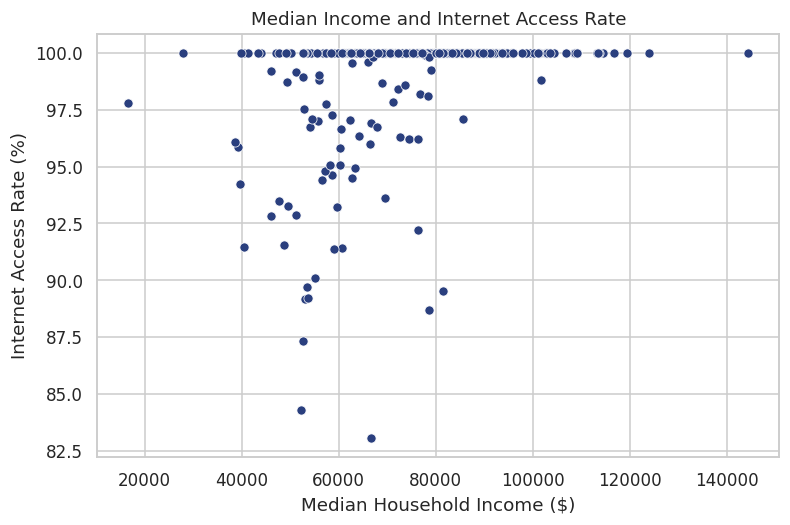

In [9]:
sns.scatterplot(
    data=model_ready_df,
    x="median_income",
    y="internet_access_rate"
)

plt.title("Median Income and Internet Access Rate")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Internet Access Rate (%)")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

**Insight statement:**  
_Write your sentence here._

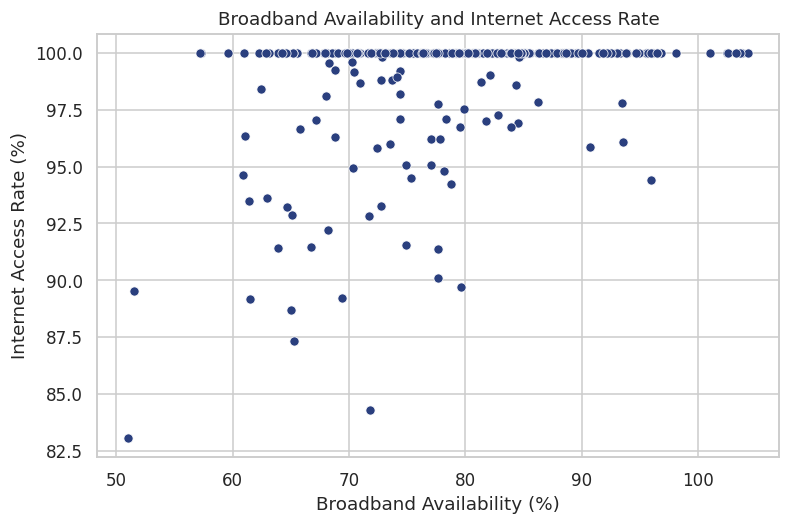

In [10]:
sns.scatterplot(
    data=model_ready_df,
    x="broadband_availability",
    y="internet_access_rate"
)

plt.title("Broadband Availability and Internet Access Rate")
plt.xlabel("Broadband Availability (%)")
plt.ylabel("Internet Access Rate (%)")
plt.show()

**Insight statement:**  
_Write your sentence here._

# 4. Define Features and Target

## Features
The input variables used to make predictions.

## Target
The outcome variable we want to predict.

Here, the target is:

`internet_access_rate`

In [11]:
X = model_ready_df[features]
y = model_ready_df[target]

X.head()

,median_income,education_rate,broadband_availability,urbanicity_score,device_access_rate
0,83940.854754,30.881055,85.569886,62.373466,83.127021
1,72511.242579,33.838009,68.778347,47.133224,78.135350
2,86658.393686,48.220230,86.696059,55.574896,83.100678
3,102414.537415,46.714073,91.556379,80.569037,86.889682
4,70785.239255,39.770082,82.134349,58.821981,82.439741


# 5. Train/Test Split

We split the data into:

- **Training set:** used to fit the model
- **Testing set:** used to evaluate model performance on unseen data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 236
Testing rows: 60


# Exercise 3: Train a Random Forest Model

A Random Forest combines many decision trees.

## Your Tasks

1. Create the model.
2. Fit the model using the training data.
3. Generate predictions for the test data.

In [13]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=6
)

rf_model.fit(X_train, y_train)
predictions = rf_model.predict(X_test)

# 6. Evaluate Model Performance

We will use three metrics:

## Mean Absolute Error (MAE)
Average absolute prediction error.

## Root Mean Squared Error (RMSE)
Average prediction error with larger errors penalized more.

## R-squared
The proportion of variation in the target explained by the model.

In [14]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R-squared:", round(r2, 3))

MAE: 1.11
RMSE: 2.06
R-squared: 0.1


## Interpreting a Low R-squared in This Teaching Dataset

If the R-squared value appears low, that does not automatically mean the model failed.

In the fallback synthetic dataset, many communities may already have internet access rates near the maximum value of 100 because the target variable is clipped. This creates a **ceiling effect**. When most outcome values are clustered near the top of the scale, the model has very little variation left to explain.

Because most communities in this synthetic dataset already have access rates near 100%, the model has little variation to predict. In a real dataset with more spread in the outcome, R-squared would typically be higher.

# Exercise 4: Interpret Model Performance

Answer the following:

1. Is the RMSE small or large relative to the internet access rate scale?
2. Does the R-squared suggest the model explains a meaningful amount of variation?
3. Could a ceiling effect be limiting the model's apparent performance?
4. Would this model be good enough for public decision-making? Why or why not?

In [15]:
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

results_df.head()

,Actual,Predicted
0,96.220920,99.600623
1,100.000000,99.574279
2,100.000000,99.647402
3,100.000000,99.502111
4,98.947199,94.900011


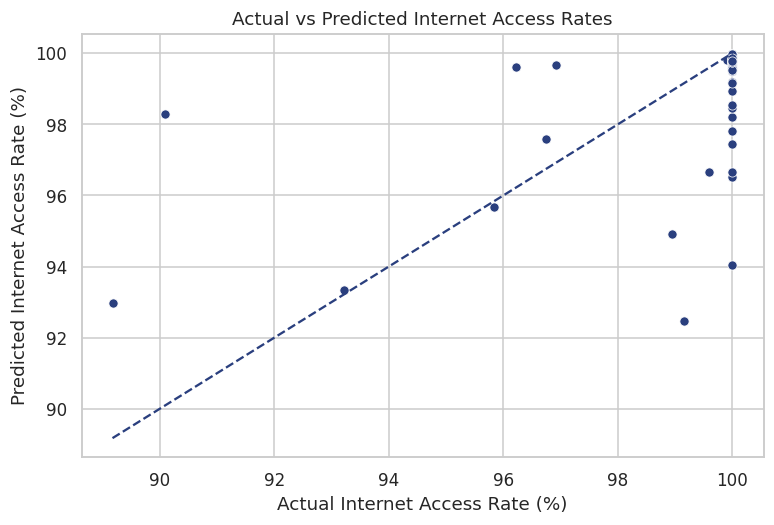

In [16]:
sns.scatterplot(
    x=results_df["Actual"],
    y=results_df["Predicted"]
)

plt.plot(
    [results_df["Actual"].min(), results_df["Actual"].max()],
    [results_df["Actual"].min(), results_df["Actual"].max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Internet Access Rates")
plt.xlabel("Actual Internet Access Rate (%)")
plt.ylabel("Predicted Internet Access Rate (%)")
plt.show()

**Insight statement:**  
_Write your responses here._

# 7. Traditional Feature Importance

Random Forest models provide feature importance scores.

These scores show which variables were most useful for reducing prediction error across the trees.

However, feature importance does not show whether a variable pushed a specific prediction higher or lower.

In [17]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
2,broadband_availability,0.383306
0,median_income,0.308903
1,education_rate,0.167845
4,device_access_rate,0.085330
3,urbanicity_score,0.054616


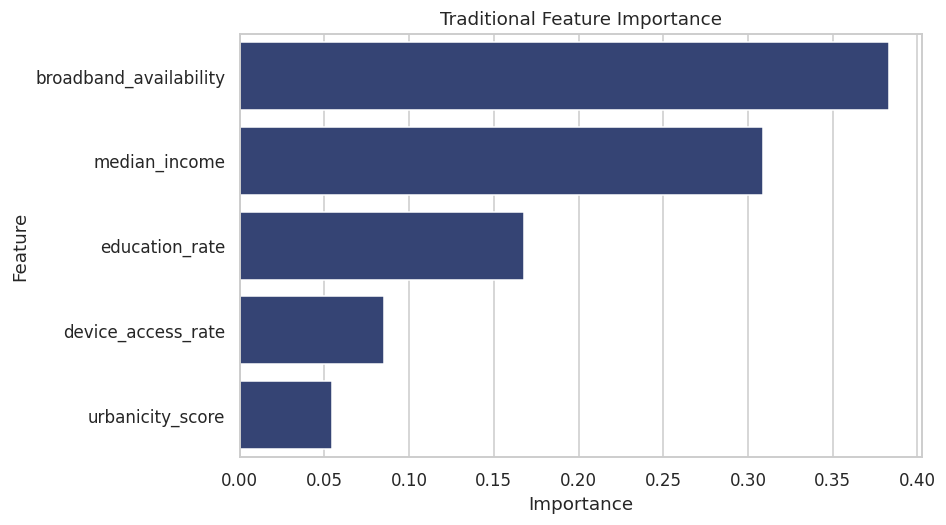

In [ ]:
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Traditional Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# 8. Introduction to SHAP Values

SHAP values explain how each feature contributes to model predictions.

For each prediction, SHAP helps answer:

- Which features pushed the prediction higher?
- Which features pushed the prediction lower?
- Which features had the greatest influence?

Traditional feature importance gives a global ranking. SHAP can provide both global and local interpretation.

# 9. Create SHAP Explainer

For tree-based models like Random Forest, we can use `shap.TreeExplainer`.

In [18]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
shap_values.shape

(60, 5)

# 10. SHAP Summary Plot

The SHAP summary plot shows:

- Which variables matter most overall
- Whether high or low values push predictions up or down

## How to read it

- Each dot is one observation.
- Position on x-axis shows impact on prediction.
- Color usually indicates feature value.
- Features at the top tend to be most influential.

/tmp/ipykernel_1785/2768415751.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=True)


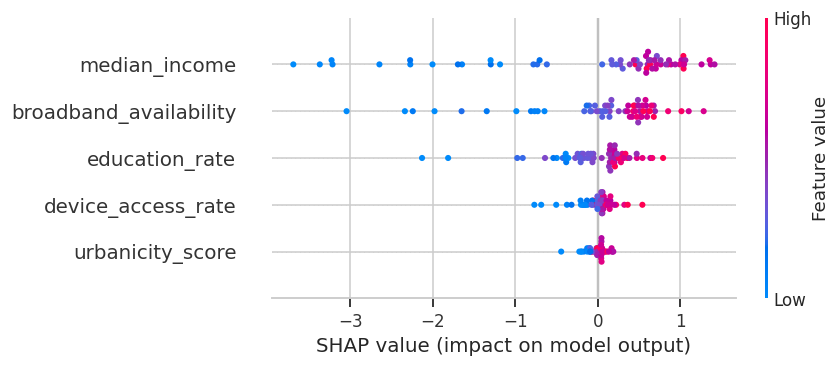

In [19]:
shap.summary_plot(shap_values, X_test, show=True)

# Exercise 5: Interpret the SHAP Summary Plot

Answer the following:

1. Which variable appears most influential overall?
2. Do higher values of that variable push predictions higher or lower?
3. Which feature has the least influence?
4. How does this compare with the traditional feature importance chart?

# 11. SHAP Bar Plot

This shows mean absolute SHAP values by feature. It gives a cleaner global ranking of feature impact.

/tmp/ipykernel_1785/1877109257.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)


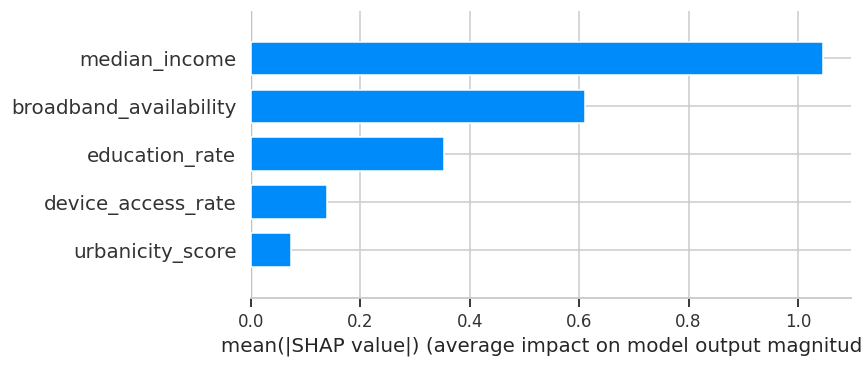

In [20]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

**Insight statement:**  
_Write your responses here._

# 12. Local Explanation for One Prediction

Now we explain one individual prediction.

In [21]:
row_index = 0

single_observation = X_test.iloc[[row_index]]
single_prediction = rf_model.predict(single_observation)[0]
actual_value = y_test.iloc[row_index]

print("Actual value:", round(actual_value, 2))
print("Predicted value:", round(single_prediction, 2))

single_observation

Actual value: 96.22
Predicted value: 99.6


,median_income,education_rate,broadband_availability,urbanicity_score,device_access_rate
278,76256.43753,23.735551,77.835771,35.228178,74.01257


In [22]:
single_shap_values = shap_values[row_index]

local_explanation = pd.DataFrame({
    "Feature": features,
    "Feature Value": single_observation.iloc[0].values,
    "SHAP Value": single_shap_values
}).sort_values(by="SHAP Value", key=abs, ascending=False)

local_explanation

,Feature,Feature Value,SHAP Value
0,median_income,76256.437530,0.826727
2,broadband_availability,77.835771,0.489578
1,education_rate,23.735551,-0.389224
3,urbanicity_score,35.228178,-0.093091
4,device_access_rate,74.012570,-0.069088


# Exercise 6: Interpret One Prediction

Use the local explanation table to answer:

1. Which feature pushed the prediction highest?
2. Which feature pushed the prediction lowest?
3. Does the explanation make sense based on the feature values?
4. What would you tell a non-technical decision-maker?

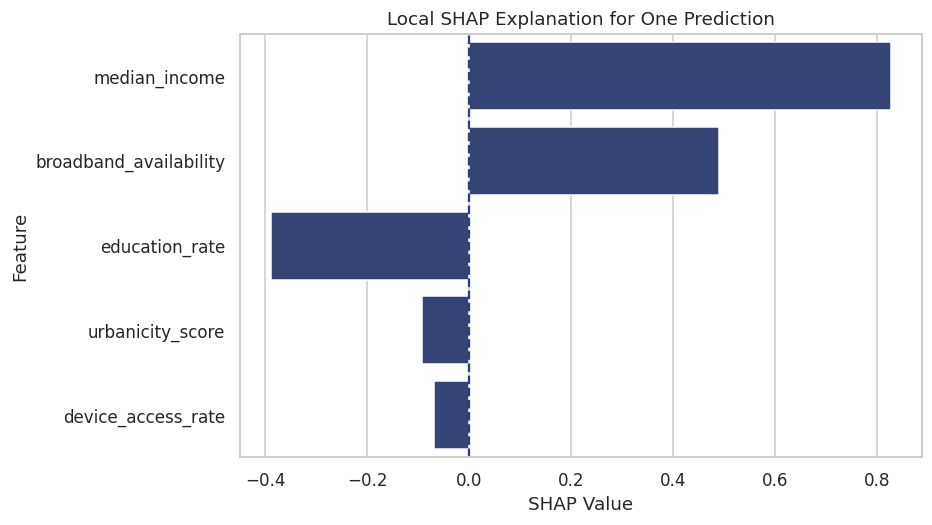

In [23]:
sns.barplot(
    data=local_explanation,
    x="SHAP Value",
    y="Feature"
)

plt.axvline(0, linestyle="--")
plt.title("Local SHAP Explanation for One Prediction")
plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.show()

**Insight statement:**  
_Write your responses here._

# 13. Optional: SHAP Waterfall Plot

A waterfall plot shows how the model moves from a baseline prediction to the final prediction.

If this cell creates display issues in Colab, use the local explanation table and bar chart above.

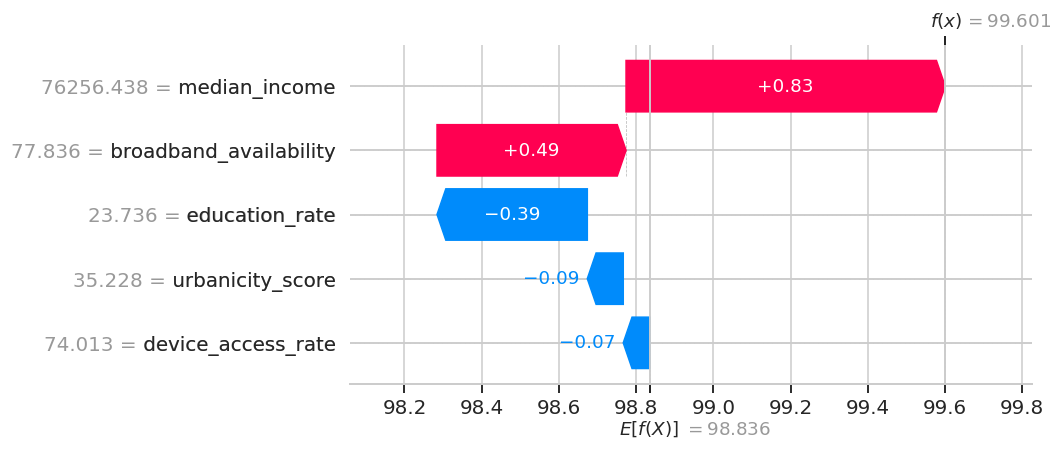

In [24]:
expected_value = explainer.expected_value

single_explanation = shap.Explanation(
    values=single_shap_values,
    base_values=expected_value,
    data=single_observation.iloc[0],
    feature_names=features
)

shap.plots.waterfall(single_explanation, show=True)

# 14. Brief Unsupervised Learning Exercise: K-Means Clustering

The slides introduced both supervised and unsupervised learning.

So far, the notebook has used **supervised learning** because we predicted a known outcome: `internet_access_rate`.

Now we will briefly use **unsupervised learning**. In unsupervised learning, the model does not predict a labeled outcome. Instead, it looks for patterns or groups in the data.

Here, we use k-means clustering to group communities based on their income and internet access profile.

In [25]:
cluster_features = model_ready_df[["median_income", "internet_access_rate"]].copy()

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
model_ready_df["cluster"] = kmeans.fit_predict(cluster_scaled)

model_ready_df[["median_income", "internet_access_rate", "cluster"]].head()

,median_income,internet_access_rate,cluster
0,83940.854754,100.000000,1
1,72511.242579,96.328368,0
2,86658.393686,100.000000,1
3,102414.537415,100.000000,1
4,70785.239255,100.000000,0


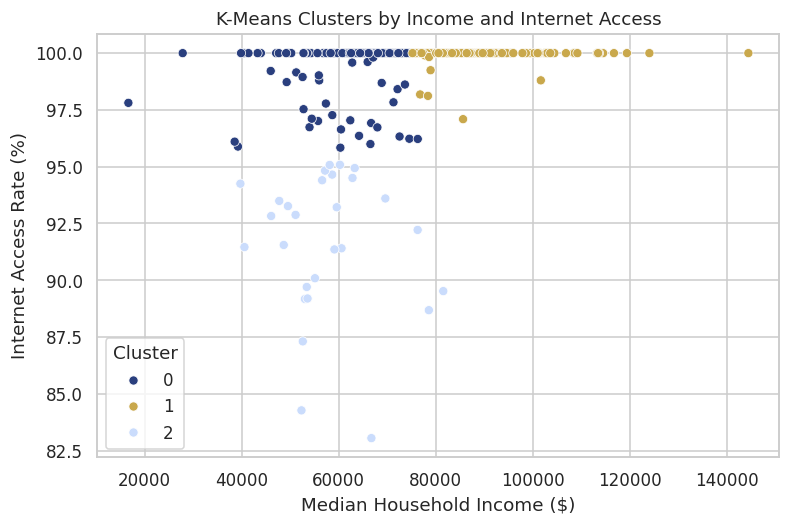

In [26]:
cluster_palette = {0: PALETTE[0], 1: PALETTE[1], 2: PALETTE[2]}

sns.scatterplot(
    data=model_ready_df,
    x="median_income",
    y="internet_access_rate",
    hue="cluster",
    palette=cluster_palette
)

plt.title("K-Means Clusters by Income and Internet Access")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Internet Access Rate (%)")
plt.ticklabel_format(style="plain", axis="x")
plt.legend(title="Cluster")
plt.show()

# Exercise 7: Interpret the Clusters

Answer the following:

1. Do the clusters appear meaningful?
2. Which cluster seems most digitally advantaged?
3. Which cluster may require additional investigation?
4. How is this different from the supervised prediction model?

**Insight statement:**  
_Write your responses here._

# 15. Responsible ML Discussion

Machine learning can help identify patterns, but it must be used carefully.

## Important questions

- Is the training data representative?
- Are there missing variables?
- Could the model reinforce existing inequalities?
- Are the predictions explainable?
- Should this model be used for decision-making, or only exploration?

**Insight statement:**  
_Write your responses here._

# Exercise 8: Decision-Making Reflection

Write a short response:

> If this model predicted that a community has low internet access, how should a public agency use that information?

Consider:

- What additional evidence is needed?
- What risks should be considered?
- How should model outputs be communicated?

**Insight statement:**  
_Write your responses here._

# Final Applied Exercise

Create a short model interpretation summary.

Your summary should include:

1. The goal of the model
2. The model type used
3. Key performance result
4. Top 2 important features
5. One SHAP-based insight
6. One limitation
7. One recommendation for next steps

## Template

This model was developed to predict...

The model achieved...

The most important features were...

The SHAP analysis suggests...

A key limitation is...

A recommended next step is...

## Final Applied Exercise Response

**Model goal:**  
...

**Model type:**  
...

**Performance:**  
...

**Top features:**  
...

**SHAP insight:**  
...

**Limitation:**  
...

**Next step:**  
...

# Key Takeaways

- Machine learning is useful for prediction, but interpretation matters.
- Traditional feature importance provides a broad ranking of variables.
- SHAP values help explain both global and individual predictions.
- Supervised learning predicts a known outcome.
- Unsupervised learning identifies patterns or groups without a target variable.
- A model can perform well and still be inappropriate for decision-making.
- Responsible ML requires technical evaluation, context, and transparency.

---

## Learning Objectives — Check-In

At the start of this workshop, we set nine goals. Review them and reflect on which you feel confident about.

1. ✅ Prepare data for machine learning
2. ✅ Understand the difference between explanation-focused and prediction-focused analysis
3. ✅ Train a Random Forest regression model
4. ✅ Evaluate model performance using MAE, RMSE, and R²
5. ✅ Interpret traditional feature importance
6. ✅ Use SHAP values to explain global model behaviour
7. ✅ Explain individual predictions using local SHAP analysis
8. ✅ Apply k-means clustering as a brief unsupervised learning exercise
9. ✅ Reflect on model limitations, fairness, and responsible use